# Customer Churn Prediction — End-to-End Starter Notebook

This notebook is designed to align with the project phases and produce portfolio-ready outputs.

## 1) Business Objective
- Predict likely churners.
- Simulate targeted retention to estimate net financial benefit.
- Primary metric: ROC-AUC; deployment threshold tuned for business trade-off.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path('../src').resolve()))
from churn_prediction.pipeline import run_training_pipeline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

## 2) Load Data

In [2]:
DATA_PATH = Path('../data/raw/customer_churn.csv')

if not DATA_PATH.exists():
    print(f'Place your dataset at: {DATA_PATH.resolve()}')
else:
    df = pd.read_csv(DATA_PATH)
    print(df.shape)
    display(df.head())

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3) Quick EDA Checks

In [3]:
if 'df' in globals():
    print('Missing values (top 15):')
    display(df.isna().sum().sort_values(ascending=False).head(15))

    

    display(df.describe(include='all').transpose().head(20))

Missing values (top 15):


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4) Baseline Training + Evaluation + Business Simulation

In [4]:
if DATA_PATH.exists():
    results = run_training_pipeline(str(DATA_PATH))
    results

## 5) Compare Model Metrics

,roc_auc,precision,recall,f1,pr_auc,brier_score,log_loss,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std
xgboost,0.842391,0.655405,0.518717,0.579104,0.652058,0.136950,0.421527,0.843291,0.010616,0.662618,0.021113,0.661037,0.034396,0.526421,0.020573,0.585648,0.020408
logistic_regression,0.840146,0.535857,0.719251,0.614155,0.633574,0.154711,0.461749,0.845486,0.012224,0.660515,0.021863,0.559659,0.017200,0.733779,0.035243,0.634804,0.022110
random_forest,0.826391,0.621951,0.545455,0.581197,0.608757,0.144197,0.442388,0.831755,0.008329,0.616044,0.021334,0.635927,0.029781,0.503010,0.022445,0.561391,0.021872


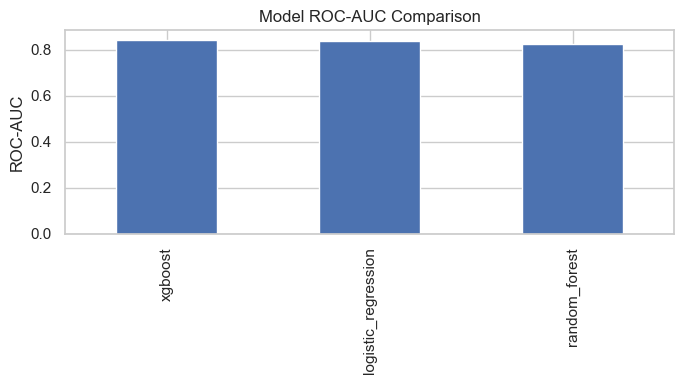

In [5]:
if 'results' in globals():
    metrics_df = pd.DataFrame(results['benchmark_results']).T.sort_values('roc_auc', ascending=False)
    display(metrics_df)

    ax = metrics_df['roc_auc'].plot(kind='bar', figsize=(7, 4), title='Model ROC-AUC Comparison')
    ax.set_ylabel('ROC-AUC')
    plt.tight_layout()
    plt.show()

## 6) Threshold & Business Impact Summary

In [6]:
if 'results' in globals():
    print('Best model:', results['best_model'])
    print('Optimal threshold:', round(results['optimal_threshold'], 3))
    print('Tuned metrics:')
    display(pd.Series(results['tuned_metrics'], name='value'))

    print('Business impact:')
    display(pd.Series(results['business_impact'], name='value'))

Best model: xgboost
Optimal threshold: 0.1
Tuned metrics:


roc_auc      0.842391
precision    0.417857
recall       0.938503
f1           0.578254
Name: value, dtype: float64

Business impact:


n_targeted                          281.0
correctly_identified_churners       188.0
retention_cost_total              14050.0
revenue_saved                    150400.0
net_benefit                      136350.0
Name: value, dtype: float64

## 7) Robust Evaluation Diagnostics

This section summarizes model stability and probability quality beyond single-threshold metrics:
- Cross-validation mean ± std (stability)
- Holdout probability quality (PR-AUC, Brier score, Log loss)
- Calibration check (predicted vs observed risk by bin)

Validation strategy:
80/20 stratified holdout + stratified cross-validation on training split
CV folds: 5

Cross-validation summary (best model):


,value
cv_roc_auc_mean,0.843291
cv_roc_auc_std,0.010616
cv_pr_auc_mean,0.662618
cv_pr_auc_std,0.021113
cv_precision_mean,0.661037
cv_precision_std,0.034396
cv_recall_mean,0.526421
cv_recall_std,0.020573
cv_f1_mean,0.585648
cv_f1_std,0.020408


Holdout probability quality:


,value
pr_auc,0.652058
brier_score,0.136950
log_loss,0.421527


,bin,count,mean_predicted_probability,observed_positive_rate
0,"[0.0, 0.1)",569.0,0.033142,0.040422
1,"[0.1, 0.2)",188.0,0.148271,0.207447
2,"[0.2, 0.3)",122.0,0.247445,0.237705
3,"[0.3, 0.4)",119.0,0.350292,0.361345
4,"[0.4, 0.5)",115.0,0.453330,0.400000
5,"[0.5, 0.6)",95.0,0.548449,0.536842
6,"[0.6, 0.7)",70.0,0.644469,0.557143
7,"[0.7, 0.8)",61.0,0.742080,0.786885
8,"[0.8, 0.9)",61.0,0.854966,0.770492
9,"[0.9, 1.0]",9.0,0.931106,1.000000


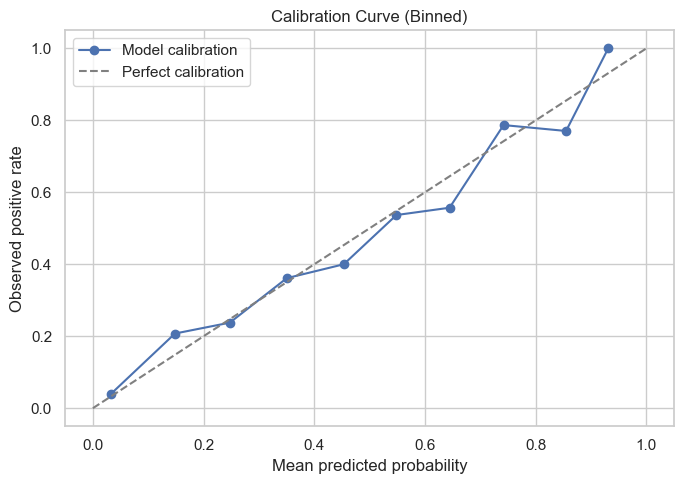

In [8]:
if 'results' in globals() and 'robust_evaluation' in results:
    robust_eval = results['robust_evaluation']

    cv_summary = pd.Series(robust_eval.get('best_model_cv_summary', {}), name='value')
    holdout_quality = pd.Series(robust_eval.get('holdout_probability_quality', {}), name='value')

    print('Validation strategy:')
    print(robust_eval.get('validation_strategy', 'N/A'))
    print(f"CV folds: {robust_eval.get('cv_folds', 'N/A')}")

    print('\nCross-validation summary (best model):')
    display(cv_summary.to_frame())

    print('Holdout probability quality:')
    display(holdout_quality.to_frame())

    calibration_rows = robust_eval.get('calibration_table', [])
    if calibration_rows:
        calibration_df = pd.DataFrame(calibration_rows)
        calibration_df['bin'] = calibration_df.apply(
            lambda row: f"[{row['bin_lower']:.1f}, {row['bin_upper']:.1f}" + ("]" if row['bin_upper'] >= 1.0 else ")"),
            axis=1,
        )

        display(
            calibration_df[
                ['bin', 'count', 'mean_predicted_probability', 'observed_positive_rate']
            ]
        )

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(
            calibration_df['mean_predicted_probability'],
            calibration_df['observed_positive_rate'],
            marker='o',
            label='Model calibration',
        )
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Observed positive rate')
        ax.set_title('Calibration Curve (Binned)')
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Run the training cell first to populate 'results' and 'robust_evaluation'.")

## 8)Interpretation



In [9]:
if 'results' in globals() and 'robust_evaluation' in results:
    robust_eval = results['robust_evaluation']
    cv = robust_eval.get('best_model_cv_summary', {})
    holdout = robust_eval.get('holdout_probability_quality', {})
    bins = pd.DataFrame(robust_eval.get('calibration_table', []))

    if not bins.empty:
        low_bin = bins.iloc[0]
        high_bin = bins.iloc[-1]
        mid_bin = bins.iloc[1] if len(bins) > 1 else bins.iloc[0]

        print('Interview summary:')
        print(
            f"1) Stability: 5-fold CV ROC-AUC = {cv.get('cv_roc_auc_mean', float('nan')):.3f} ± {cv.get('cv_roc_auc_std', float('nan')):.3f}, showing consistent ranking performance across folds."
        )
        print(
            f"2) Probability quality: Holdout PR-AUC = {holdout.get('pr_auc', float('nan')):.3f}, Brier = {holdout.get('brier_score', float('nan')):.3f}, Log loss = {holdout.get('log_loss', float('nan')):.3f}."
        )
        print(
            f"3) Calibration: Low-risk bin ({low_bin['bin_lower']:.1f}-{low_bin['bin_upper']:.1f}) predicted {low_bin['mean_predicted_probability']:.3f} vs observed {low_bin['observed_positive_rate']:.3f}; high-risk bin ({high_bin['bin_lower']:.1f}-{high_bin['bin_upper']:.1f}) predicted {high_bin['mean_predicted_probability']:.3f} vs observed {high_bin['observed_positive_rate']:.3f}, with mild underestimation around the {mid_bin['bin_lower']:.1f}-{mid_bin['bin_upper']:.1f} range."
        )
    else:
        print('Calibration table is empty. Re-run training and diagnostics cells.')
else:
    print("Run the training and robust diagnostics cells first to populate interpretation outputs.")

Interview summary:
1) Stability: 5-fold CV ROC-AUC = 0.843 ± 0.011, showing consistent ranking performance across folds.
2) Probability quality: Holdout PR-AUC = 0.652, Brier = 0.137, Log loss = 0.422.
3) Calibration: Low-risk bin (0.0-0.1) predicted 0.033 vs observed 0.040; high-risk bin (0.9-1.0) predicted 0.931 vs observed 1.000, with mild underestimation around the 0.1-0.2 range.


## 9) SHAP Explainability Artifact

This section shows:
- SHAP summary plot saved from pipeline execution
- Top SHAP features with actionable direction insights

,feature,mean_abs_shap,insight
0,tenure,0.641005,Higher values tend to reduce churn risk.
1,TotalCharges = 19.9,0.548310,Presence of this category tends to increase ch...
2,Contract = Month-to-month,0.522441,Presence of this category tends to increase ch...
3,TotalCharges = 20.15,0.493098,Category appears infrequently; effect estimate...
4,TotalCharges = 19.75,0.341510,Presence of this category tends to reduce chur...
5,Contract = Two year,0.309942,Presence of this category tends to increase ch...
6,PaymentMethod = Electronic check,0.269148,Presence of this category tends to reduce chur...
7,TotalCharges = 45.3,0.251437,Category appears infrequently; effect estimate...


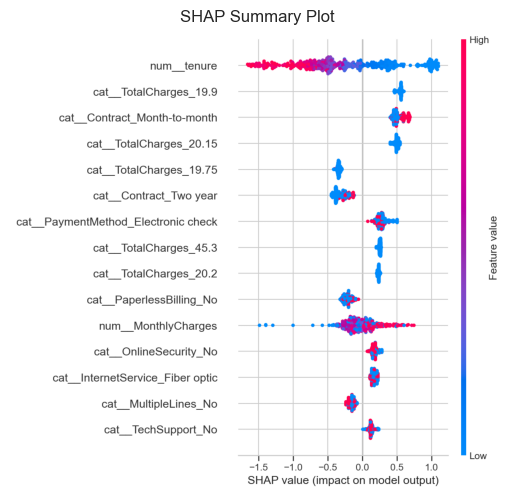

In [5]:
if 'results' in globals() and 'explainability' in results:
    explain = results['explainability']

    if 'error' in explain:
        print(explain['error'])
    else:
        top_features = pd.DataFrame(explain.get('top_features', []))
        if not top_features.empty:
            top_features = top_features.sort_values('mean_abs_shap', ascending=False)
            display(top_features)

        summary_path = explain.get('shap_summary_plot_path')
        if summary_path and Path(summary_path).exists():
            image = plt.imread(summary_path)
            plt.figure(figsize=(10, 6))
            plt.imshow(image)
            plt.axis('off')
            plt.title('SHAP Summary Plot')
            plt.show()
        else:
            print('SHAP summary plot path not found.')
else:
    print("Run the training cell first to populate 'results[\"explainability\"]'.")